## Main Code


In [7]:
import networkx as nx                  # Untuk membuat dan memvisualisasikan graf
import matplotlib.pyplot as plt        # Untuk menampilkan graf
from collections import defaultdict    # Untuk membuat dictionary otomatis

# Kelas Graph digunakan untuk menyimpan dan mengelola graf
class Graph:
    def __init__(self):
        self.graph = defaultdict(list)  # Menyimpan adjacency list tiap vertex
        self.edges = []                 # Menyimpan semua edge beserta bobotnya

    # Fungsi untuk menambahkan edge ke dalam graf
    def buat_edge(self, u, v, w):
        self.graph[u].append(v)         # Tambah tetangga v ke vertex u
        self.graph[v].append(u)         # Tambah tetangga u ke vertex v (graf tak berarah)
        self.edges.append((u, v, w))    # Simpan edge (u, v) beserta bobot w

    # DFS untuk mencari lintasan/sirkuit Euler
    def dfs_euler(self, node, visited_edge, jalur):
        for neighbor in self.graph[node]:
            edge = tuple(sorted((node, neighbor)))  # Normalisasi edge agar (u,v) == (v,u)
            if edge not in visited_edge:            # Lewati edge yang sudah dikunjungi
                visited_edge.add(edge)              # Tandai edge sebagai sudah dikunjungi
                self.dfs_euler(neighbor, visited_edge, jalur)  # Rekursi ke tetangga
        jalur.append(node)                          # Tambahkan node ke jalur setelah semua tetangga diproses

    # Mengecek apakah graf memiliki lintasan atau sirkuit Euler
    def check_euler(self):
        odd = 0
        for node in self.graph:
            if len(self.graph[node]) % 2 != 0:  # Hitung vertex dengan derajat ganjil
                odd += 1
        if odd == 0:                            # Semua derajat genap → Sirkuit Euler
            return 2
        elif odd == 2:                          # Tepat 2 derajat ganjil → Lintasan Euler
            return 1
        else:                                   # Lebih dari 2 derajat ganjil → Bukan Euler
            return 0

    # Mencari lintasan atau sirkuit Euler
    def cari_euler(self):
        hasil = self.check_euler()              # Cek tipe Euler dari graf
        if hasil == 0:
            return None                         # Tidak ada lintasan/sirkuit Euler
        start = None
        if hasil == 1:
            for node in self.graph:             # Cari vertex berderajat ganjil sebagai titik awal
                if len(self.graph[node]) % 2 != 0:
                    start = node
                    break
        else:
            start = list(self.graph.keys())[0]  # Untuk sirkuit, mulai dari vertex pertama
        visited_edge = set()                    # Set untuk melacak edge yang sudah dilalui
        jalur = []                              # List untuk menyimpan urutan jalur
        self.dfs_euler(start, visited_edge, jalur)  # Jalankan DFS Euler mulai dari start
        return jalur[::-1]                      # Balik urutan jalur (DFS mengisi dari belakang)

    # Menampilkan visualisasi graf
    def draw_graph(self):
        G = nx.Graph()                          # Buat objek graf NetworkX
        for u, v, w in self.edges:
            G.add_edge(u, v, weight=w)          # Tambahkan setiap edge beserta bobotnya
        pos = nx.spring_layout(G, seed=42)      # Tentukan posisi node dengan layout spring (seed=42 agar konsisten)
        plt.figure(figsize=(10, 7))             # Buat kanvas gambar ukuran 10x7 inci
        nx.draw(G, pos, with_labels=True, node_size=3000,
                node_color="skyblue", font_size=12, font_weight="bold")  # Gambar node dan label
        labels = nx.get_edge_attributes(G, 'weight')    # Ambil bobot semua edge
        nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)         # Tampilkan bobot di sisi edge
        plt.title("Graf Euler dengan DFS")
        plt.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1)   # Atur margin gambar
        plt.show()

## Pengujian Menggunakan Data Real



HASIL ANALISIS
Graf memiliki Sirkuit Euler
Sirkuit Euler:
FIKK -> FP -> FK -> FIKK -> FBS -> FIP -> FP -> FBS -> FK -> FIP -> FIKK


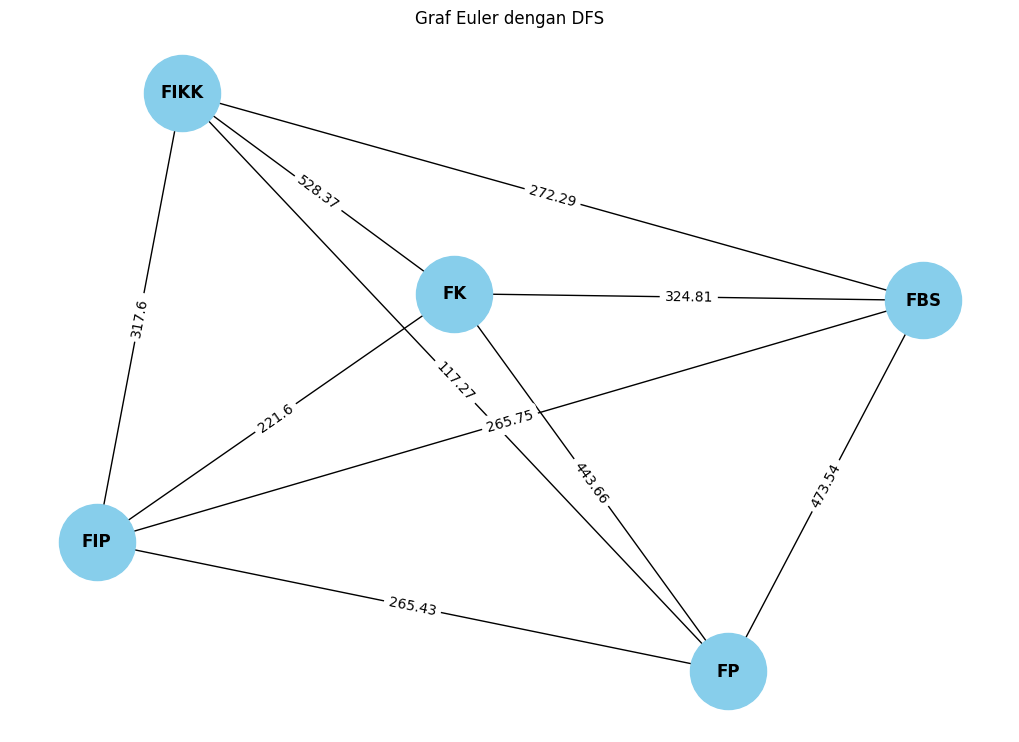

In [8]:
g = Graph()                             # Inisialisasi objek Graf baru

data_edges = [
    ("FIKK", "FP",  117.27),           # Edge antara FIKK dan FP dengan bobot 117.27
    ("FIKK", "FBS", 272.29),           # Edge antara FIKK dan FBS dengan bobot 272.29
    ("FIKK", "FIP", 317.60),           # Edge antara FIKK dan FIP dengan bobot 317.60
    ("FIKK", "FK",  528.37),           # Edge antara FIKK dan FK  dengan bobot 528.37
    ("FP",   "FK",  443.66),           # Edge antara FP   dan FK  dengan bobot 443.66
    ("FP",   "FIP", 265.43),           # Edge antara FP   dan FIP dengan bobot 265.43
    ("FBS",  "FIP", 265.75),           # Edge antara FBS  dan FIP dengan bobot 265.75
    ("FBS",  "FK",  324.81),           # Edge antara FBS  dan FK  dengan bobot 324.81
    ("FIP",  "FK",  221.60),           # Edge antara FIP  dan FK  dengan bobot 221.60
    ("FBS",  "FP",  473.54),           # Edge antara FBS  dan FP  dengan bobot 473.54
]

for u, v, w in data_edges:
    g.buat_edge(u, v, w)               # Masukkan setiap edge ke dalam objek graf

hasil = g.check_euler()                # Cek apakah graf memiliki sifat Euler

print("\nHASIL ANALISIS")
if hasil == 0:
    print("Graf bukan lintasan maupun sirkuit Euler")   # Tidak memenuhi syarat Euler
elif hasil == 1:
    print("Graf memiliki Lintasan Euler")               # Tepat 2 vertex berderajat ganjil
    jalur = g.cari_euler()                              # Cari dan simpan jalur Euler
    print("Lintasan Euler:")
    print(" -> ".join(jalur))                           # Tampilkan jalur dengan separator " -> "
else:
    print("Graf memiliki Sirkuit Euler")                # Semua vertex berderajat genap
    jalur = g.cari_euler()                              # Cari dan simpan sirkuit Euler
    print("Sirkuit Euler:")
    print(" -> ".join(jalur))                           # Tampilkan sirkuit dengan separator " -> "

g.draw_graph()                         # Visualisasikan graf beserta bobot edge-nya

## Pengujian Menggunakan Input Pengguna

In [ ]:
g = Graph()                                     # Inisialisasi objek Graf baru untuk input manual

jumlah = int(input("Masukkan jumlah edge: "))   # Minta pengguna memasukkan jumlah edge

for i in range(jumlah):
    print(f"\nEdge ke-{i+1}")
    u = input("Vertex awal  : ")                # Masukkan nama vertex awal edge
    v = input("Vertex akhir : ")                # Masukkan nama vertex akhir edge
    w = int(input("Bobot edge   : "))           # Masukkan bobot edge (dikonversi ke integer)
    g.buat_edge(u, v, w)                        # Tambahkan edge ke dalam graf

hasil = g.check_euler()                         # Cek tipe Euler dari graf yang diinput

print("\nHASIL ANALISIS")
if hasil == 0:
    print("Graf bukan lintasan maupun sirkuit Euler")   # Tidak memenuhi syarat Euler
elif hasil == 1:
    print("Graf memiliki Lintasan Euler")               # Tepat 2 vertex berderajat ganjil
    jalur = g.cari_euler()                              # Cari dan simpan lintasan Euler
    print("Lintasan Euler:")
    print(" -> ".join(jalur))                           # Tampilkan lintasan dengan separator " -> "
else:
    print("Graf memiliki Sirkuit Euler")                # Semua vertex berderajat genap
    jalur = g.cari_euler()                              # Cari dan simpan sirkuit Euler
    print("Sirkuit Euler:")
    print(" -> ".join(jalur))                           # Tampilkan sirkuit dengan separator " -> "

g.draw_graph()                                  # Visualisasikan graf input manual